# Machine Learning Foundations
**Data Preparation
**Assigment 1****

Raya Metchkarova

In [928]:
# all of the necessary libraries for data preparation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)




## Pipeline Order Justification (Task: Task Ordering)

1. **Identifying the Prediction Target** – Must be first; we need to know what we are predicting before any exploration.
2. **Data Loading and Exploration** – Understand the data structure, distributions, and missingness patterns.
3. **Data Splitting** – **Critical**: must happen *before* any transformation that learns from data. Splitting here ensures that validation and test sets remain unseen throughout preprocessing.
4. **Managing Missing Values** – Imputation strategies (e.g., mode, median) must be *fitted on the training set only* and applied to val/test.
5. **Encoding Categorical Variables** – Encoders (e.g., OrdinalEncoder) must be *fitted on training only*.
6. **Feature Scaling** – Scalers must be *fitted on training only*; fitting on all data would leak test distribution.
7. **Feature Selection** – Variance/correlation thresholds computed on training data only.
8. **Addressing Class Imbalance** – Resampling applied to *training set only*; test/val must preserve original distribution.
9. **Training a Logistic Regression Model** – Final sanity check.


 ## Identifying the Prediction Target


In [929]:
df = pd.read_csv('bank-additional.csv', sep=';')
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)

Shape of the dataset: (4119, 21)
Columns in the dataset: Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


The target variable in this dataset is 'y', which indicates whether the client subscribed to a term deposit (yes or no). This variable is what we want to predict based on the other features in the dataset. The 'y' variable is binary, with possible values 'yes' and 'no', making it a classification problem. The goal is to build a model that can predict whether a client will subscribe to a term deposit, after being contacted, based on the various features provided in the dataset, such as age, job, marital status, education, and previous campaign outcomes.

2 varibales that could look like targets but are not:
- `duration`: This variable represents the duration of the last contact in seconds. It is not a target variable because it is not what we want to predict; rather, it is a feature that could potentially influence the target variable 'y'. Moreover, 'duration' is only known after the contact has occurred, so it cannot be used for prediction at the time of contact.
- `poutcome`: This variable indicates the outcome of the previous marketing campaign. While it provides information about past interactions with the client, it is not the target variable we want to predict. Instead, it is a feature that may have predictive power for the target variable 'y', as past campaign outcomes could influence a client's likelihood of subscribing to a term deposit in the current campaign.


In [930]:
TARGET = 'y'
print("Target variable:", TARGET)
print(df[TARGET].value_counts())

Target variable: y
y
no     3668
yes     451
Name: count, dtype: int64


---
## Data Loading and Initial Exploration

In [931]:
df.info()
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [932]:
# Looking for difirancig numeric vs categorical variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


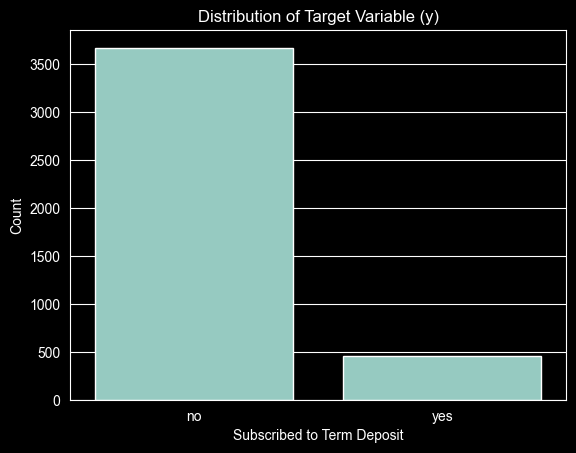

In [933]:
# distribution of the target variable
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

In [934]:
print(f'Ratio of classes in target variable:{df[TARGET].value_counts(normalize=True)}')

Ratio of classes in target variable:y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The target is highly imbalanced, with a majority of 'no' responses. (**~89%** 'no' and **~10.9%** 'yes').
- This imbalance will need to be addressed during model training, as it can lead to biased predictions towards the majority class.
- The bank's goal is to identify potential subscribers, meaning that we want minimise false negatives (missed subscribers) while also controlling false positives (wasted calls).

In [935]:
# Checking for missing values
# explicitly checking for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [936]:
# Checking for missing values stated as 'unknown'
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of unknown values in categorical columns: {unknown_values}, ({(unknown_values/len(df)*100).round(2)}%)\n")

Count of unknown values in categorical columns: job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64, (job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [937]:
# Special sentinel in pdays: 999 means "not previously contacted"
print(f'\npdays == 999: {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')


pdays == 999: 3959 (96.1%)


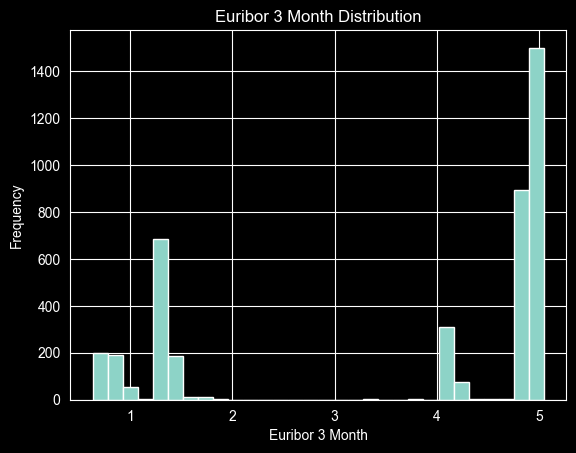

In [938]:
# age distribution
df['age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

 # euribor3m distribution
df['euribor3m'].hist(bins=30)
plt.title('Euribor 3 Month Distribution')
plt.xlabel('Euribor 3 Month')
plt.ylabel('Frequency')
plt.show()

**The 'age' distribution:** suggests that the majority of clientele are between 30 and 60 years old, with a peak around 40-50. Moderately right-skewed, indicating fewer younger and older clients. This may reflect the bank's target demographic for term deposits, as middle-aged individuals are often more financially stable and likely to invest in such products.

**The 'euribor3m' distribution:** is right-skewed, with the majority of values concentrated at the bottom (0-5), and a long tail extending to higher values. This shows that the majority of clients were contacted during periods of low interest rates, which may have influenced their decision to open a term deposit.

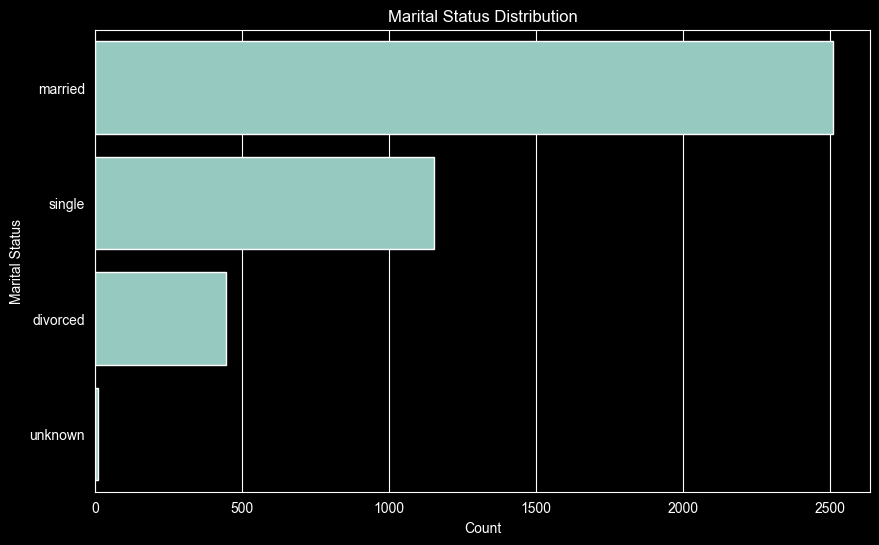

In [939]:
# job distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Job Distribution')
plt.xlabel('Count')
plt.ylabel('Job')


#education distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Education Distribution')
plt.xlabel('Count')
plt.ylabel('Education')

# marital distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='marital', data=df, order=df['marital'].value_counts().index)
plt.title('Marital Status Distribution')
plt.xlabel('Count')
plt.ylabel('Marital Status')



**The 'job' distribution:** the most common vocations among clients are "blue-collar", "management", and "technician".

**The 'education' distribution:** shows that the majority of clients have a secondary education, while fewer have a primary or tertiary education. These distributions contain information about the clients' demographic features, which may influence their likelihood of subscribing to a term deposit.

**The 'marital' status distribution:** shows that most clients are married, followed by single and divorced.

### **Special consideration for 'pdays':**
 999 indicates "not previously contacted". This is a form of implicit missingness. (Drawing this in a graph will create extreme skewness, duo to the unreasonambly big number) We will handle this by creating a new binary feature indicating whether the client was previously contacted, and then replacing 999 with 0 in the pdays column. This way, we can retain all the data without losing any information due to imputation or deletion.

---
## Data Slitting

Data splitting is a crucial step in the machine learning pipeline, as it allows us to evaluate the performance of our model on unseen data. We will split the dataset into a training set and a test set. The training set will be used to train the model, while the test set will be used to evaluate its performance. Data leakage is a cocern when information from the test set is used during training, which can lead to overly optimistic performance estimates. To prevent it we need to split the data before any preprocessing steps that learn from the data (e.g., imputation, encoding, scaling). This way, the test set remains completely unseen and provides a reliable estimate of how the model will perform on new, unseen data.

**Proportions:**
With a dataset of 41,188 rows, we will use a 70-15-15 split:
- Training set: 70% (28,832 rows) — used for fitting the model. Large to learn complex patterns, run SMOTE, fit preprocessing objects.
- Validation set: 15% (6,178 rows) — used for tuning hyperparameters and selecting features
- Test set: 15% (6,178 rows) — used for final performance evaluation. Not used in any way during model development.

**Stratification**:
  on 'y' is crucial: the class imbalance (~11% positive) means that random splits may result in significantly different class ratios, inflating or deflating assessment measures.

In [940]:
X=df.drop(columns=[TARGET])
y = df[TARGET]

# first split into train and temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# second split temp into val and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


print(f'Train: {X_train.shape[0]} rows ({(y_train=="yes").mean()*100:.1f}% positive)')
print(f'Val:   {X_val.shape[0]} rows ({(y_val=="yes").mean()*100:.1f}% positive)')
print(f'Test:  {X_test.shape[0]} rows ({(y_test=="yes").mean()*100:.1f}% positive)')

Train: 2883 rows (11.0% positive)
Val:   618 rows (11.0% positive)
Test:  618 rows (10.8% positive)


Stratification preserves the ~11% positive rate across all three splits, as confirmed above.

---
# Managing Missing Values

All transformations are derived from the **training set structure only** — here, since the strategy involves no statistical estimation (no mean/mode imputation), there is no fitting step that could leak. However, for consistency in a sklearn Pipeline, these would be fit on train.

**Explicit missing values:** (NaN) are absent in this dataset.

**Implicit missing values:**
- `unknown`: job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome have 'unknown' as a category.
- `pdays` :  has 999 to indicate "not previously contacted".

We will handle these missing values by treating 'unknown' as a separate category for the categorical variables and replacing 999 for 0 value for pdays. This way, we can retain all the data without losing any information due to imputation or deletion.

In [941]:
def handle_pdays(X):
    X = X.copy()
    X['was_contacted_before'] = (X['pdays'] != 999).astype(int)
    X = X.drop(columns=['pdays'])  # Replace pdays with the binary indicator. We dont realy want to keep the pdays column because it has a very skewed distribution and the 999 value is not meaningful for modeling. The new binary feature captures the essential information about whether the client was previously contacted, which is more relevant for our prediction task.
    return X

X_train = handle_pdays(X_train)
X_val = handle_pdays(X_val)
X_test = handle_pdays(X_test)

print('was_contacted_before value counts in training set:\n', X_train['was_contacted_before'].value_counts())

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns ### change to string because of the new column
print('unknown values in categorical columns after handling pdays:\n', X_train[cat_cols].apply(lambda x: (x == 'unknown').sum()))

was_contacted_before value counts in training set:
 was_contacted_before
0    2764
1     119
Name: count, dtype: int64
unknown values in categorical columns after handling pdays:
 job             25
marital          7
education      112
default        577
housing         65
loan            65
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64


The `unknown` categories are retained as legitimate categories that will be handled naturally by One-Hot Encoding in the next step.


---
## Encoding Categorical Variables

### Nominal versus Ordinal Classification
**Ordinal** (a meaningful order exists):
- `education`: illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree < unknown

**Nominal** (without intrinsic order):
- `'job','marital', 'contact','month', 'day_of_week', 'poutcome', 'default', 'housing', 'loan'`

### Encoding Strategy

- **Ordinal variables → `OrdinalEncoder`**: Maintains order, enabling Logistic Regression to learn monotonic correlations without increasing dimensionality.
- **Nominal variables → `OneHotEncoder` (OHE)**: No artificial ordering applied. We remove one category per variable to avoid the dummy variable trap (multicollinearity).

**All encoders are only used on the training set** to avoid leaking the distribution of unseen categories into the model.

## Impact on Logistic Regression
- OHE increases dimensionality (each category becomes a binary column), therefore coefficients can be directly interpreted as log-odds for that category versus the discarded reference.
- Ordinal encoding maintains a single column while assuming equidistant steps, which is appropriate for `education` given its natural progression.- These encodings enable the linear decision boundary to function properly in feature space.

In [942]:
print("Categorical variables: ",cat_cols)

Categorical variables:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [943]:
# Define ordinal order for education
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree', 'unknown']

ordinal_cols = ['education']
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

print('Ordinal columns:', ordinal_cols)
print('Nominal columns:', nominal_cols)

Ordinal columns: ['education']
Nominal columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [944]:
# we build the encoder
ordinal_enc = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=-1)
nominal_enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

cat_transformer = ColumnTransformer(transformers=[
    ('ordinal', ordinal_enc, ordinal_cols),
    ('nominal', nominal_enc, nominal_cols)
], remainder='passthrough')

# fit the encoder on the training data
X_train_enc = cat_transformer.fit_transform(X_train)
X_val_enc = cat_transformer.transform(X_val)
X_test_enc = cat_transformer.transform(X_test)

# reconstructing the feature names after encoding
nominal_feature_names = cat_transformer.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
num_passthrough_cols = [col for col in X_train.columns if col not in ordinal_cols + nominal_cols ]
all_cols_enc = list(ordinal_cols) + list(nominal_feature_names )+ num_passthrough_cols

X_train_enc = pd.DataFrame(X_train_enc, columns=all_cols_enc)
X_val_enc = pd.DataFrame(X_val_enc, columns=all_cols_enc)
X_test_enc = pd.DataFrame(X_test_enc, columns=all_cols_enc)

print('Dimension of training set before encoding:', X_train.shape[1])
print('Dimension of training set after encoding:', X_train_enc.shape[1])

Dimension of training set before encoding: 20
Dimension of training set after encoding: 47


The encoding increased the dimensionality of the dataset from 20 to 47 colums. OHE introduces one binary feature per category level (minus one reference), enabling the linear model to fit category-specific intercepts.

---
## Feature Scaling

All numerical features are on different scales (e.g., `age` ∈ [18, 98], `euribor3m` ∈ [0.6, 5.0], `nr.employed` ∈ [4963, 5228]). The binary OHE columns already lie in [0, 1] and the ordinal column is already low-magnitude — but standardizing them is harmless.

### Scaling Strategy: **StandardScaler** (z-score normalization)
**Justification:**
- Logistic regression optimises a convex loss using gradient descent. When features have significantly different scales, the loss surface becomes extended along large-scale dimensions, slowing convergence or generating numerical instability.
- Standardisation ensures that all features contribute similarly to the gradient update.
- **Comparable coefficients:** Following standardisation, the magnitude of LR coefficients reflects the relative relevance of each feature; otherwise, coefficients are muddled by feature scale.
- **Regularisation (L2):**`sklearn's LogisticRegression` uses L2 by default. L2 penalises the squared magnitude of coefficients. Without scaling, large-scale characteristics are penalised less in absolute terms, rendering regularisation imbalanced.


**Scaler is fitted solely on training data**; fitting on val/test would leak their mean and variance, providing the scaler with knowledge of the test distribution.

In [945]:
# we build the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_cols_enc)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=all_cols_enc)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=all_cols_enc)

print('Scaling is done.')
print('Training mean (should be ~0):', X_train_scaled.mean().mean().round(2))
print('Training std (should be ~1):', X_train_scaled.std().mean().round(2))

Scaling is done.
Training mean (should be ~0): -0.0
Training std (should be ~1): 1.0


---
## Feature Selection

Feature selection must use the **training set only**. Computing variances or correlations on the full dataset would incorporate test distribution information into the selection decision, constituting leakage.

### Low Variance Features


In [946]:
# Threshold: variance < 0.01 (feature is nearly constant)
var_threshold = VarianceThreshold(threshold=.01)
var_threshold.fit(X_train_scaled)

low_var_mask = ~var_threshold.get_support()
low_var_features = X_train_scaled.columns[low_var_mask].tolist()

print('Low variance features (var<.01):', low_var_features)
if not low_var_features:
    print('No low variance features found.')

Low variance features (var<.01): []
No low variance features found.


In [947]:
# Apply variance filter
# this is not needed in this case since we found no low-variance features, but we will do it for the sake of the pipeline
selected_features = X_train_scaled.columns[var_threshold.get_support()].tolist()
X_train_sel = X_train_scaled[selected_features]
X_val_sel   = X_val_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f'Features after variance filter: {len(selected_features)}')

Features after variance filter: 47


Low-variance features contain little to no variability between samples, hence they give little information for separating across classes. Removing them could reduce noise levels and enhance model performance. In this scenario, we discovered no low-variance features, indicating that all characteristics have some variability and may contribute to the model's predictive capacity.

In [948]:
# correlation analysis
corr_matrix = X_train_sel.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row,col]) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.85]

print('Highly correlated feature pairs (corr>0.85):')
for feat1, feat2, corr_value in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f'{feat1} - {feat2}: {corr_value:.2f}')

Highly correlated feature pairs (corr>0.85):
loan_unknown - housing_unknown: 1.00
euribor3m - emp.var.rate: 0.97
nr.employed - euribor3m: 0.94
was_contacted_before - poutcome_success: 0.93
nr.employed - emp.var.rate: 0.90


### Correlation analysis

Highly correlated features (|r| > 0.85) can cause multicollinearity in Logistic Regression. Leading to unstable coefficient estimates and difficulties in interpretation.
- The model can not distinguish which of the correlated features is driving the relationship with the target, resulting in inflated standard errors and unreliable p-values.
- Removing one of the correlated features can improve model stability and interpretability without sacrificing predictive power, as the remaining feature captures the shared information.


In [949]:
# Compute correlation matrix on training set only
corr_matrix = X_train_sel.corr().abs()

# Find pairs with |r| > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.85]

print('Highly correlated pairs (|r| > 0.85):')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {a} — {b}: {r:.2f}')

Highly correlated pairs (|r| > 0.85):
  loan_unknown — housing_unknown: 1.00
  euribor3m — emp.var.rate: 0.97
  nr.employed — euribor3m: 0.94
  was_contacted_before — poutcome_success: 0.93
  nr.employed — emp.var.rate: 0.90


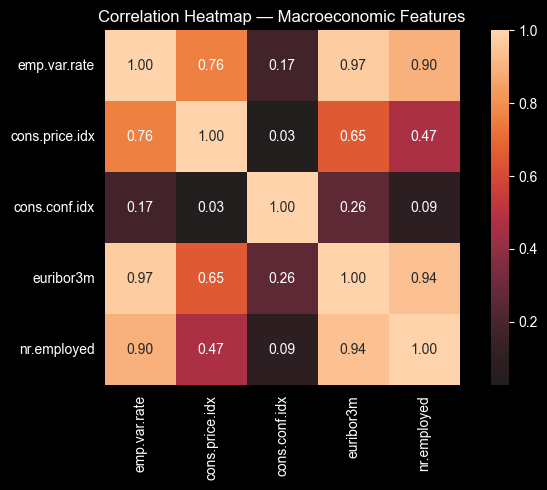

In [950]:

# visualize correlation heatmap
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
macro_in_sel = [c for c in macro_cols if c in selected_features]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(X_train_sel[macro_in_sel].corr(), annot=True, fmt='.2f',
            center=0, ax=ax, square=True) # if I want pink add: cmap='PuRd',
ax.set_title('Correlation Heatmap — Macroeconomic Features')
plt.tight_layout()
plt.show()

The heatmap reveals extreme multicollinearity among the macroeconomic indicators:
- `euribor3m` — `emp.var.rate`: r ≈ 0.97
- `euribor3m` — `nr.employed`: r ≈ 0.94

The macroeconomic features (`euribor3m`, `emp.var.rate`, and `nr.employed`) are closely connected, since they all reflect the same underlying economic cycle.

Multicollinearity in Logistic Regression increases coefficient variance and destabilises interpretation. We eliminate the most redundant ones, leaving 'euribor3m' (the most direct rate indication) and 'cons.conf.idx' (an independent consumer sentiment signal).

In [951]:
# Remove highly correlated features
# duo to the corellation > 0.94 we will remove 'emp.var.rate' and 'nr.employed' and keep 'euribor3m' and 'cons.conf.idx' (euribor3m — emp.var.rate: 0.970; nr.employed — euribor3m: 0.942)

cols_to_drop_corr= [c for c in ['emp.var.rate', 'nr.employed'] if c in selected_features ]
print('Dropping highly correlated features:', cols_to_drop_corr)

X_train_final = X_train_sel.drop(columns=cols_to_drop_corr)
X_val_final   = X_val_sel.drop(columns=cols_to_drop_corr)
X_test_final  = X_test_sel.drop(columns=cols_to_drop_corr)

print('Final feature count after selection:', X_train_final.shape[1])

Dropping highly correlated features: ['emp.var.rate', 'nr.employed']
Final feature count after selection: 45


---
## Addressing Class Imbalance

In [952]:
# Quantify imbalance
print('Class distribution in training set:')
print(y_train.value_counts())
print(f'Imbalance ratio (no/yes): {(y_train=="no").sum()}/{ (y_train=="yes").sum()} = {(y_train=="no").sum()/(y_train=="yes").sum():.1f}:1')

Class distribution in training set:
y
no     2567
yes     316
Name: count, dtype: int64
Imbalance ratio (no/yes): 2567/316 = 8.1:1


The imbalance of 8:1 is a matter for concern:
- A simple model predicting 'no' for every customer achieves ~88% accuracy, indicating the Zero Rule baseline is surprisingly high.
- **Accuracy:** is deceptive since it fails to discriminate between false positives (wasted calls) and false negatives (missed conversions).
- **Precision and Recall:** on the minority class are more informative—the bank is concerned with locating actual subscribers (high Recall) rather than spending resources on non-subscribers (high Precision).
- **F1 Score:** balances Precision and Recall, providing a single metric to optimise for the minority class.

## Resampling Strategy: **SMOTE** (Synthetic Minority Over-Sampling Technique)

SMOTE creates synthetic minority samples by interpolating existing minority cases rather than duplicating them. This:
- Prevents overfitting to repeated points (risk of random oversampling)
- Adds new coverage to the minority class feature area.- Is suitable for tabular and numerical data (after encoding).

**SMOTE applies just to the training set.** To provide accurate performance estimates, the validation and test sets must retain the original distribution. If SMOTE was used before splitting, synthetic points might emerge in both training and testing, resulting in data leakage and overoptimistic assessment.

In [953]:
y_train_b = (y_train == "yes").astype(int)  # Keep as pandas Series
y_val_b   = (y_val == "yes").astype(int)
y_test_b  = (y_test == "yes").astype(int)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_final, y_train_b)

print('Class distribution before SMOTE:', y_train_b.value_counts())
print('Class distribution after SMOTE:', pd.Series(y_train_res).value_counts())

Class distribution before SMOTE: y
0    2567
1     316
Name: count, dtype: int64
Class distribution after SMOTE: y
0    2567
1    2567
Name: count, dtype: int64


After SMOTE the training set is balanced 1:1. Validation and test remain at the original ~11% positive rate, ensuring that performance metrics reflect real-world conditions.

---
## Training a Logistic Regression Model

We train a Logistic Regression model on the resampled training set. The goal is not to maximise performance but to ensure that the entire pipeline is functional and produces reasonable results.

In [954]:
# Train logistic regression on the resampled training set
# Filter out numerical warnings from sklearn internals

model = LogisticRegression( # all of those things are beacouse of errors
    max_iter=10000,  # big iterations for better convergence
    random_state=42,
    C=0.01,  # Strong regularization to prevent coefficient explosion
    solver='saga',  # More robust solver that handles numerical issues better
    n_jobs=-1,  # Use all CPU cores
    warm_start=False,
    tol=1e-4  # Convergence tolerance
)
model.fit(X_train_res, y_train_res)

y_val_pred = model.predict(X_val_final)
y_test_pred = model.predict(X_test_final)


acc  = accuracy_score(y_val_b, y_val_pred)
prec = precision_score(y_val_b, y_val_pred)
rec  = recall_score(y_val_b, y_val_pred)
f1   = f1_score(y_val_b, y_val_pred)

acc_test = accuracy_score(y_test_b, y_test_pred)
prec_test = precision_score(y_test_b, y_test_pred)
rec_test = recall_score(y_test_b, y_test_pred)
f1_test = f1_score(y_test_b, y_test_pred)

zero_rule_acc = (y_val_b == 0).mean()  # always predict majority class

print(f'\nZero Rule Baseline Accuracy: {zero_rule_acc:.3f}')
print(f'\nLogistic Regression Validation Performance:')
print(f'  Accuracy:  {acc:.3f}')
print(f'  Precision: {prec:.3f}')
print(f'  Recall:    {rec:.3f}')
print(f'  F1 Score:  {f1:.3f}')

print(f'\nLogistic Regression Test Performance:')
print(f'  Accuracy:  {acc_test:.3f}')
print(f'  Precision: {prec_test:.3f}')
print(f'  Recall:    {rec_test:.3f}')
print(f'  F1 Score:  {f1_test:.3f}')


Zero Rule Baseline Accuracy: 0.890

Logistic Regression Validation Performance:
  Accuracy:  0.862
  Precision: 0.436
  Recall:    0.853
  F1 Score:  0.577

Logistic Regression Test Performance:
  Accuracy:  0.877
  Precision: 0.460
  Recall:    0.776
  F1 Score:  0.578


---
## Model Evaluation and Interpretation

### Matrics reporting: Accuracy, Precision, Recall, F1 Score
We evaluate on the **validation set**, which preserves the original class distribution (~11% positive). This means the metrics are realistic estimates of campaign performance.

**Zero Rule baseline:** A classifier that always predicts `no` achieves ~89% accuracy. Any useful model must significantly exceed this baseline on the metrics that matter: **Recall** and **F1 on the positive class**.

**Interpreting the confusion matrix:**
- **True Positives (TP):** Correctly identified subscribers — the model's primary goal.
- **False Negatives (FN):** Subscribers predicted as non-subscribers — missed revenue opportunities for the bank.
- **False Positives (FP):** Non-subscribers predicted as subscribers — wasted call resources.
- **True Negatives (TN):** Correctly identified non-subscribers — efficient targeting.

Given the bank's objective (find subscribers, minimise wasted calls), a high **Recall** is most valuable. A model with high precision but low recall is overly conservative and misses many real subscribers.


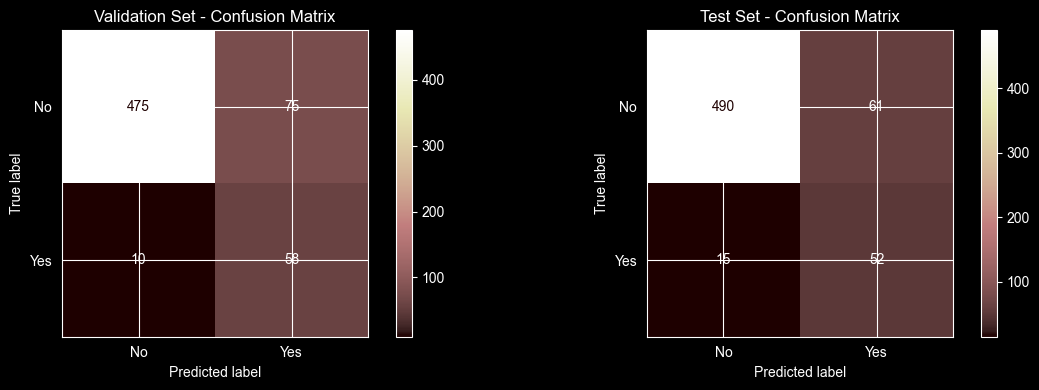

In [955]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Validation confusion matrix
cm_val = confusion_matrix(y_val_b, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['No', 'Yes'])
disp_val.plot(ax=axes[0], cmap='pink')
axes[0].set_title('Validation Set - Confusion Matrix')

# Test confusion matrix
cm_test = confusion_matrix(y_test_b, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No', 'Yes'])
disp_test.plot(ax=axes[1], cmap='pink')
axes[1].set_title('Test Set - Confusion Matrix')

plt.tight_layout()
plt.show()

In [956]:
# Classification reports
print('Validation Set Classification Report:')
print(classification_report(y_val_b, y_val_pred, target_names=['No', 'Yes']))

print('\nTest Set Classification Report:')
print(classification_report(y_test_b, y_test_pred, target_names=['No', 'Yes']))

Validation Set Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.86      0.92       550
         Yes       0.44      0.85      0.58        68

    accuracy                           0.86       618
   macro avg       0.71      0.86      0.75       618
weighted avg       0.92      0.86      0.88       618


Test Set Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.89      0.93       551
         Yes       0.46      0.78      0.58        67

    accuracy                           0.88       618
   macro avg       0.72      0.83      0.75       618
weighted avg       0.91      0.88      0.89       618



---
## Model Coefficient Analysis


Because all features were standardised before training, the Logistic Regression coefficients are expressed in **comparable units**: each coefficient represents the change in log-odds of subscription per one standard deviation increase in that feature. This allows us to directly compare the influence of features that originally had very different scales.

A **positive coefficient** means that higher values of the feature (or presence of that OHE category) are associated with a higher probability of subscription. A **negative coefficient** means the opposite. The magnitude reflects the strength of association, after accounting for all other features and the L2 regularisation penalty.


In [957]:
# Get feature names and coefficients
feature_names = X_train_final.columns
coefficients = model.coef_[0]

# Create a dataframe for easier interpretation
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print('\nTop 10 Most Influential Features (by absolute coefficient value):')
print(coef_df.head(10))

print('\nIntercept:', model.intercept_[0])


Top 10 Most Influential Features (by absolute coefficient value):
              Feature  Coefficient
38           duration     1.505372
43          euribor3m    -0.863200
27          month_may    -0.304906
42      cons.conf.idx     0.287719
25          month_jun     0.255566
21  contact_telephone    -0.253763
26          month_mar     0.251016
36   poutcome_success     0.246271
6   job_self-employed    -0.236732
39           campaign    -0.211151

Intercept: -1.4518439817285909


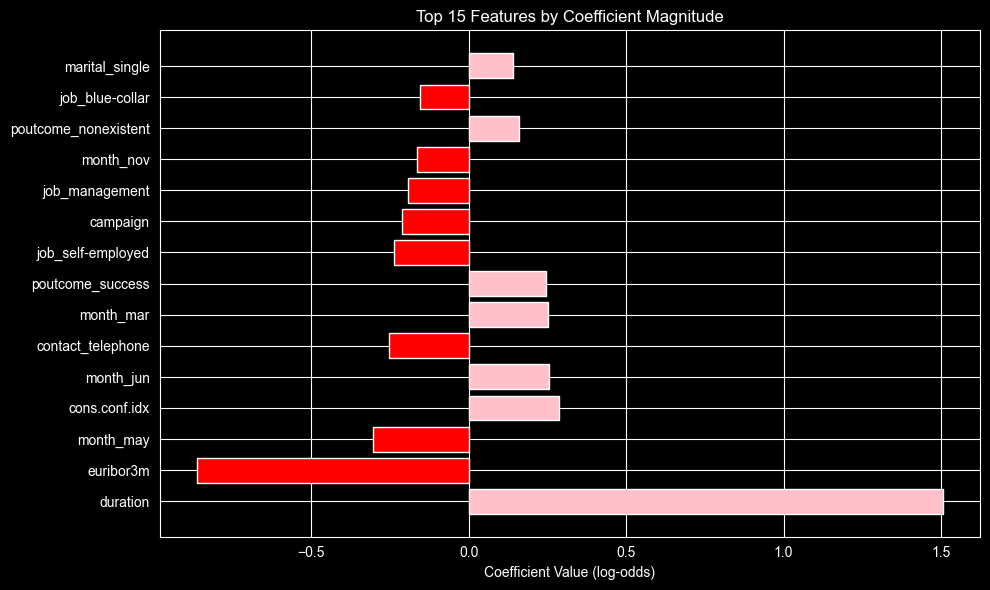

In [958]:
# Visualize top coefficients
top_f_n = 15
top_coef = coef_df.head(top_f_n)

plt.figure(figsize=(10, 6))
colors = ['pink' if x > 0 else 'red' for x in top_coef['Coefficient']]
plt.barh(range(len(top_coef)), top_coef['Coefficient'], color=colors)
plt.yticks(range(len(top_coef)), top_coef['Feature'])
plt.xlabel('Coefficient Value (log-odds)')
plt.title(f'Top {top_f_n} Features by Coefficient Magnitude')
plt.axvline(x=0, color='white', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


### Coefficient Interpretation

- **Positive coefficients** (pink): These features increase the estimated log-odds of subscription. For example, a positive coefficient on `euribor3m` would suggest that clients contacted during higher-rate periods are more likely to subscribe — though given the bimodal distribution, this relationship may reflect campaign-era effects rather than individual behaviour.
- **Negative coefficients** (red): These features decrease the log-odds of subscription. A negative coefficient on an OHE job category means clients in that occupational group are less likely to subscribe relative to the reference category.
- **Magnitude:** Because features are standardised, larger absolute coefficients indicate stronger predictive influence. Note that the L2 regularisation (`C=0.01`, i.e., strong regularisation) has shrunk all coefficients toward zero — the relative ordering of magnitudes is more informative than the absolute values.

### Check

If the preprocessing pipeline is correct, we expect:
- The model to outperform the Zero Rule baseline on F1 and Recall for the positive class.
- Coefficients to be numerically stable (no NaN or infinity), which we explicitly verify before plotting.
- Val and test metrics to be broadly comparable — large discrepancies would suggest overfitting or a subtle leakage issue to investigate.
